# Temporal Decay (Rolling-Horizon Generalization) -- EDA

Visualizes the output of `run_temporal_decay_experiment`
(`thesis.experiments.temporal_decay`): for each shortlisted config, a
schema+model is mined/fit once on window 0's train split (W_src is always
the first window -- no other source-window role) and frozen, then walked
forward one window at a time to the end of the timeline. `h=0` is W_src's
own held-out test split; every horizon after that is a fully external
window. This notebook draws the decay curve (primary metric and FPR vs.
horizon), the decay-summary table (h=0 vs. the last horizon reached), and
the SHAP + LIME feature-importance drift across horizon for a selected
config.

In [1]:
from __future__ import annotations

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from thesis.paths import ARTIFACTS_DIR

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Thresholds

Edit and re-run below -- nothing past this cell needs to change.

In [2]:
SCENARIO = "cscas"
RUN_ID = None  # None -> latest run dir for SCENARIO

PRIMARY_METRIC = "auc"  # which metric to draw as the main degradation curve
SOURCE_COLOR = "#CC3311"  # h=0 (W_src's own held-out test split)
LINE_COLOR = "#4477AA"

# Which config's SHAP/LIME drift to plot in section 3 -- see the printed
# config list in that section, then set this to its row index.
CONFIG_SELECT = 0
TOP_K_FEATURES = 8  # features shown per drift plot, ranked by mean |importance|

In [3]:
sweep_dir = ARTIFACTS_DIR / "experiments" / "temporal_decay" / SCENARIO
# Only consider run directories -- sweep_dir also holds
# _derived_shortlist.csv (written by --structural-configs runs), and
# sorting unfiltered would pick that file as "latest" since "_" sorts after
# digits, then crash trying to treat it as a directory.
run_dirs = [p for p in sweep_dir.iterdir() if p.is_dir()]
run_dir = sweep_dir / RUN_ID if RUN_ID else sorted(run_dirs)[-1]

per_horizon = pd.read_csv(run_dir / "per_horizon_results.csv")
decay_summary = pd.read_csv(run_dir / "decay_summary.csv")
explanations = pd.read_csv(run_dir / "explanations.csv")
lime_fidelity = pd.read_csv(run_dir / "lime_fidelity.csv")

print(f"Loaded from {run_dir}")
print(f"per_horizon_results: {len(per_horizon)} rows")
print(f"decay_summary:       {len(decay_summary)} rows")
print(f"explanations:         {len(explanations)} rows")
print(f"lime_fidelity:        {len(lime_fidelity)} rows")
per_horizon.head()

Loaded from /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/temporal_decay/cscas/20260713_222406
per_horizon_results: 133 rows
decay_summary:       21 rows
explanations:         7980 rows
lime_fidelity:        133 rows


,scenario,feature_set,mining_setting,granularity,model,n_windows,threshold_mode,threshold,mining_cache_hit,horizon_window_index,horizon_fraction,is_source_window,target_single_class,n_alert_groups,n_attack,auc,accuracy,precision,recall,f1,tp,fp,tn,fn,fpr
0,cscas,symbolic,gr3_md1_mda2,0.25,logreg,4,fixed,0.5,True,0,0.000000,True,False,104649,1277,0.999246,0.995948,0.750735,1.000000,0.857623,1277,424,102948,0,0.004102
1,cscas,symbolic,gr3_md1_mda2,0.25,logreg,4,fixed,0.5,True,1,0.333333,False,False,348831,6853,0.995646,0.992833,0.739676,0.980155,0.843103,6717,2364,339614,136,0.006913
2,cscas,symbolic,gr3_md1_mda2,0.25,logreg,4,fixed,0.5,True,2,0.666667,False,False,348831,4737,0.992301,0.994229,0.707749,0.979523,0.821748,4640,1916,342178,97,0.005568
3,cscas,symbolic,gr3_md1_mda2,0.25,logreg,4,fixed,0.5,True,3,1.000000,False,False,348831,5228,0.970867,0.993736,0.721955,0.946634,0.819167,4949,1906,341697,279,0.005547
4,cscas,symbolic,gr3_md1_mda2,0.20,logreg,5,fixed,0.5,True,0,0.000000,True,False,83719,920,0.998273,0.994362,0.662791,0.991304,0.794425,912,464,82335,8,0.005604


## 1. Degradation curves

One small-multiple per config: metric vs. horizon (window index), walking
forward from window 0 to the end of the timeline. The `h=0` point --
W_src's own held-out test split, never seen by mining or fitting -- is
marked with a star in a different color; every other point is a fully
external window.

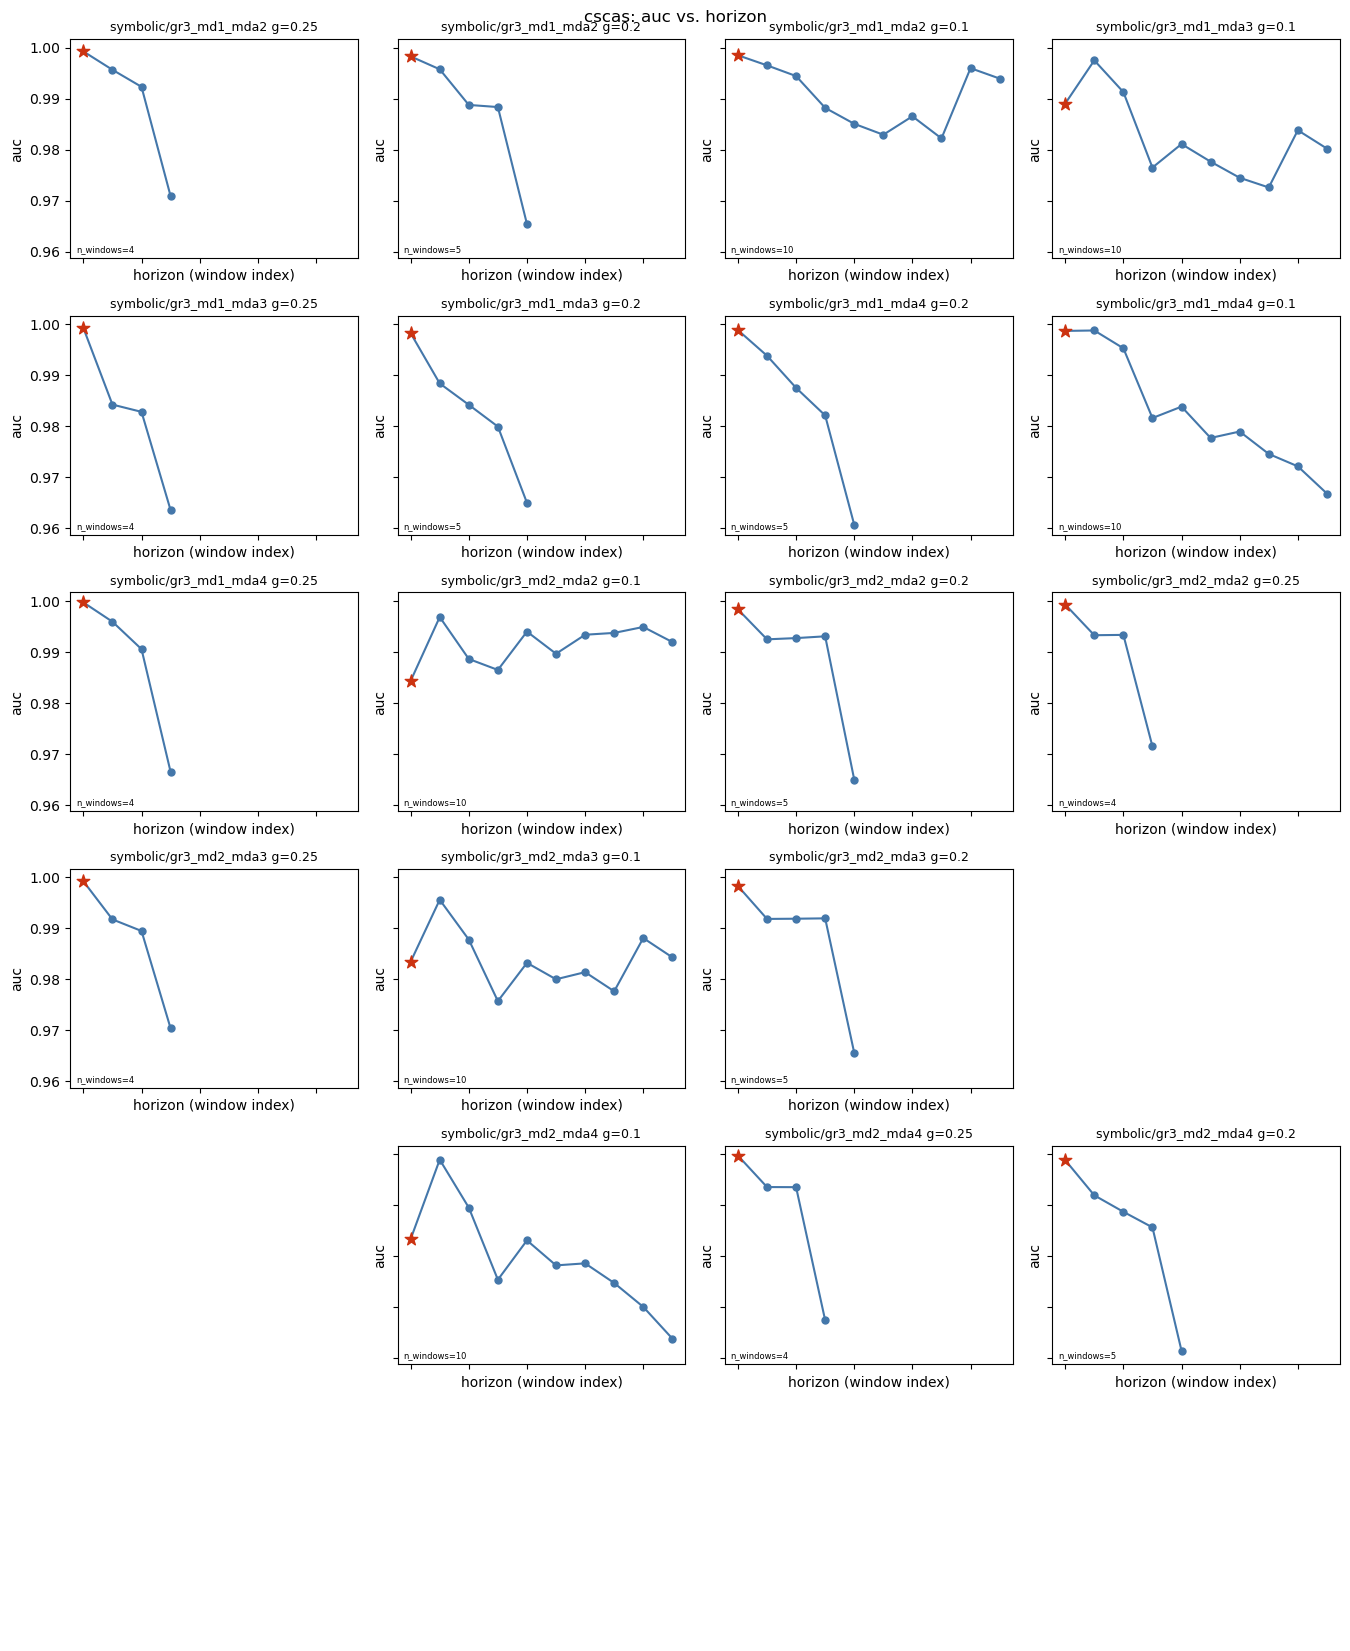

In [4]:
CONFIG_COLS = ["feature_set", "mining_setting", "granularity", "model"]


def config_label(row) -> str:
    return (
        f"{row['feature_set']}/{row['mining_setting']} "
        f"g={row['granularity']:g}"
    )


def plot_degradation_curves(metric: str, title: str) -> None:
    configs = per_horizon[CONFIG_COLS].drop_duplicates().reset_index(drop=True)
    n = len(configs)
    ncols = 4
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.4 * ncols, 2.8 * nrows), squeeze=False,
        sharex=True, sharey=True,
    )

    for i, cfg_row in configs.iterrows():
        ax = axes[i // ncols][i % ncols]
        mask = (per_horizon[CONFIG_COLS] == cfg_row).all(axis=1)
        sub = per_horizon[mask].sort_values("horizon_window_index")
        if sub.empty or metric not in sub.columns:
            ax.axis("off")
            continue

        source = sub[sub["is_source_window"]]
        rest = sub[~sub["is_source_window"]]

        ax.plot(sub["horizon_window_index"], sub[metric], "-", color=LINE_COLOR, zorder=1)
        ax.scatter(rest["horizon_window_index"], rest[metric], color=LINE_COLOR, zorder=3, s=25)
        if not source.empty:
            ax.scatter(
                source["horizon_window_index"], source[metric],
                color=SOURCE_COLOR, marker="*", s=90, zorder=5,
                label="W_src held-out (h=0)",
            )

        ax.set_title(config_label(cfg_row), fontsize=9)
        ax.text(
            0.02, 0.02, f"n_windows={int(sub['n_windows'].iloc[0])}",
            transform=ax.transAxes, fontsize=6, va="bottom",
        )
        ax.set_xlabel("horizon (window index)")
        ax.set_ylabel(metric)

    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")

    fig.suptitle(title)
    fig.tight_layout()


# sharey=True above: a shared y-axis across all subplots is deliberate --
# each subplot used to auto-scale its own y-range independently, which made
# a config sitting at 0.94-0.99 and one sitting at 0.97-1.0 both render as
# "a wiggly line spanning most of its own box," visually near-identical even
# when the underlying numbers genuinely differed. A common range makes
# actual magnitude differences between configs visible at a glance.
plot_degradation_curves(PRIMARY_METRIC, f"{SCENARIO}: {PRIMARY_METRIC} vs. horizon")

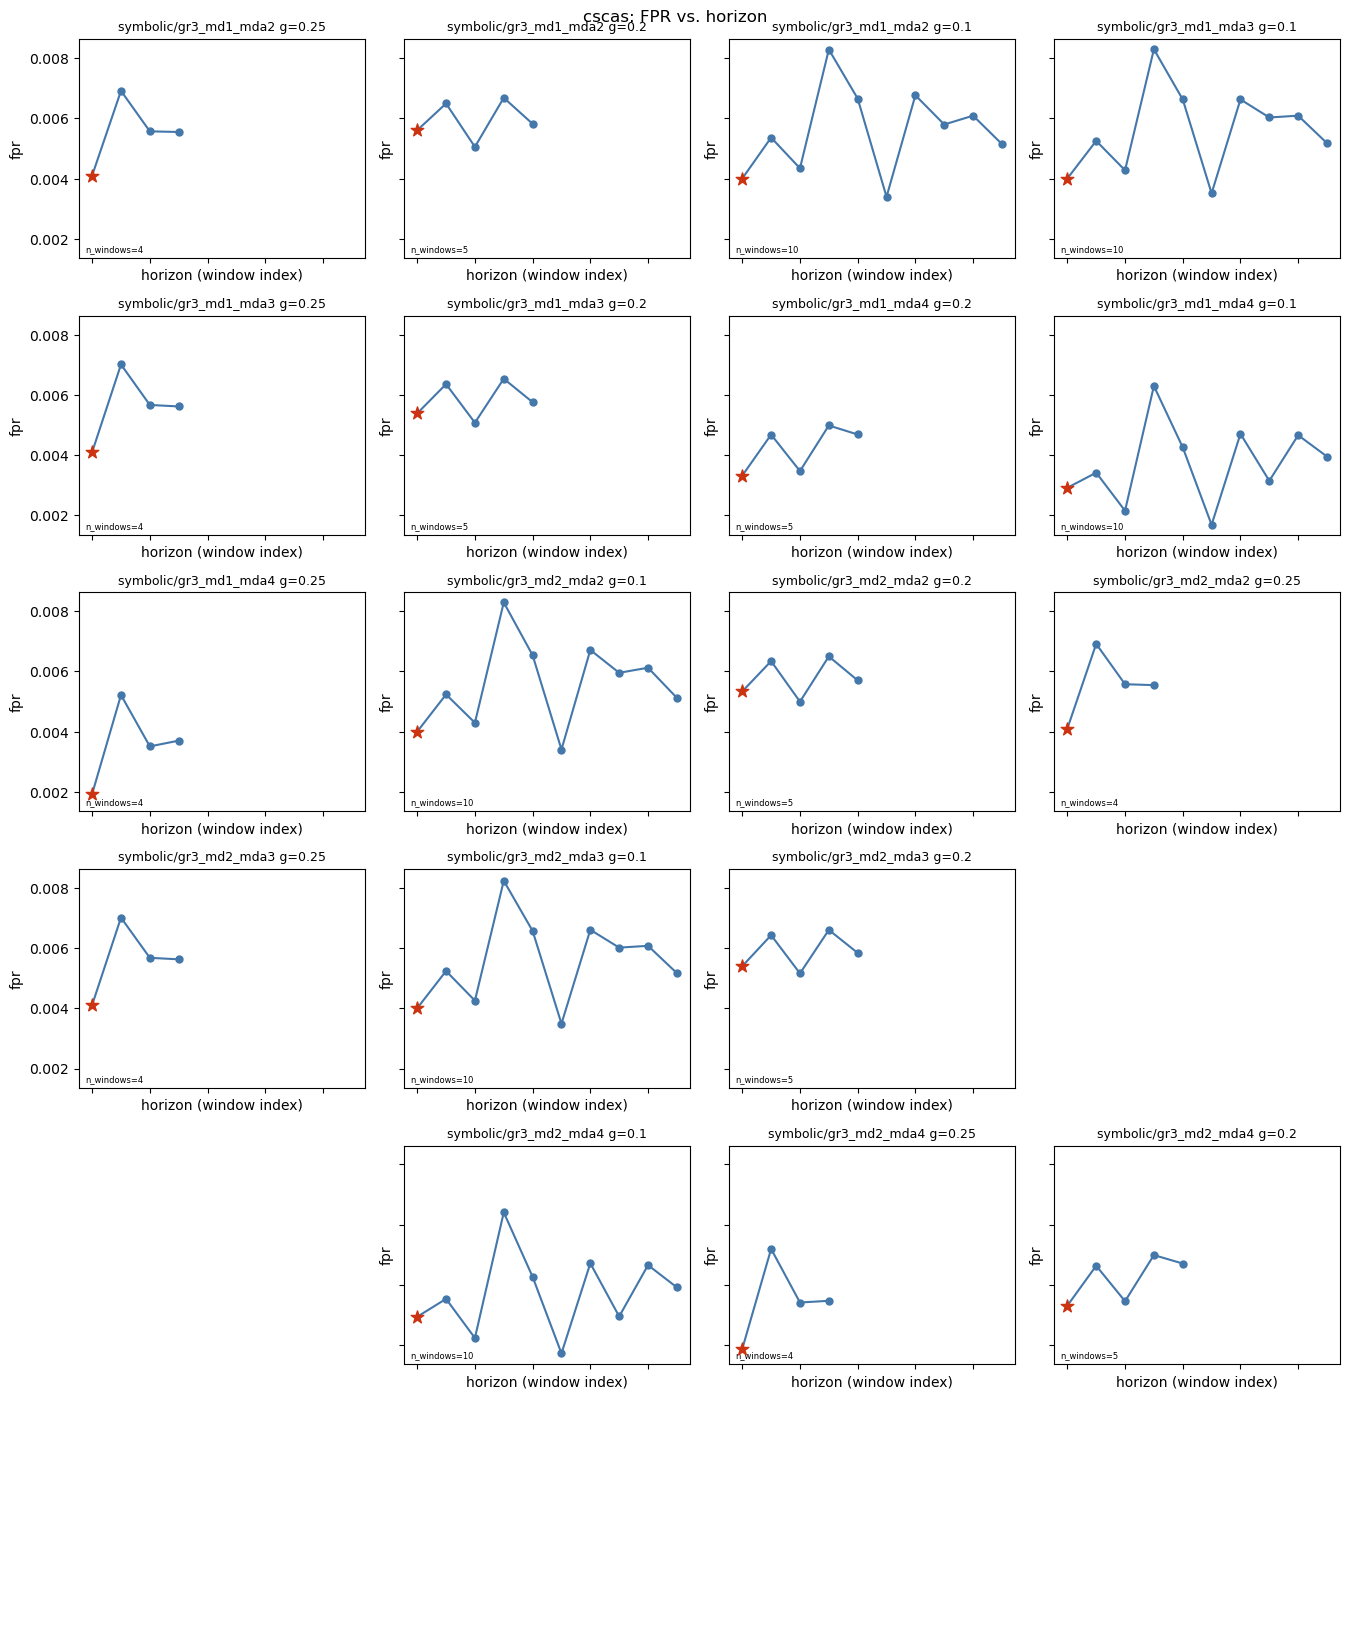

In [5]:
plot_degradation_curves("fpr", f"{SCENARIO}: FPR vs. horizon")

### Near-duplicate configs check

Two configs can look identical in the plots above for a real reason, not a
plotting bug: AUC is a rank statistic, so if one mining setting's extra
itemsets (e.g. a looser contrast-set `min_growth_rate` threshold) only add
*weak*, marginal predicates that a regularized logistic regression shrinks
toward irrelevance, the model's ranking of alert groups -- and therefore its
AUC -- barely moves, even though the mined schemas themselves are genuinely
different (different feature counts, different cache fingerprints). This
cell checks the raw numbers directly rather than relying on eyeballing
pixels: any two configs whose per-horizon metric values match within
`atol` at every horizon they share are flagged below. A non-empty result
here is a signal worth taking to Experiment 1's shortlist -- those configs'
mining-setting axis (independent of granularity) may not be doing
meaningful work for this scenario.

In [6]:
def find_near_duplicate_configs(df: pd.DataFrame, metric: str, atol: float = 1e-6) -> pd.DataFrame:
    pivot = df.pivot_table(index="horizon_window_index", columns=CONFIG_COLS, values=metric)
    configs = list(pivot.columns)
    rows = []
    for i in range(len(configs)):
        for j in range(i + 1, len(configs)):
            a, b = pivot[configs[i]], pivot[configs[j]]
            shared = a.notna() & b.notna()
            if shared.sum() == 0:
                continue
            diff = (a[shared] - b[shared]).abs()
            if diff.max() <= atol:
                rows.append({
                    "config_a": config_label(dict(zip(CONFIG_COLS, configs[i]))),
                    "config_b": config_label(dict(zip(CONFIG_COLS, configs[j]))),
                    "n_shared_horizons": int(shared.sum()),
                    "max_abs_diff": float(diff.max()),
                })
    return pd.DataFrame(rows)


near_dupes = find_near_duplicate_configs(per_horizon, PRIMARY_METRIC, atol=1e-6)
if near_dupes.empty:
    print(f"No config pairs with identical {PRIMARY_METRIC} (within 1e-6) at every shared horizon.")
else:
    print(
        f"{len(near_dupes)} config pair(s) with near-identical {PRIMARY_METRIC} at every "
        "shared horizon -- see the markdown note above before assuming this is a plotting bug:"
    )
near_dupes

No config pairs with identical auc (within 1e-6) at every shared horizon.


""


## 2. Decay summary

Score/FPR at `h=0` (W_src's own held-out test split) vs. the last horizon
actually reached (`h_max`, the final window of the timeline), and their
difference (`decay_rate_{metric} = score(h=0) - score(h_max)`;
`fpr_drift = fpr(h_max) - fpr(h=0)`).

In [7]:
sort_col = f"decay_rate_{PRIMARY_METRIC}"
decay_summary.sort_values(sort_col, ascending=False) if sort_col in decay_summary.columns else decay_summary

,feature_set,mining_setting,granularity,model,h_max,auc_at_h0,auc_at_h9,decay_rate_auc,f1_at_h0,f1_at_h9,decay_rate_f1,accuracy_at_h0,accuracy_at_h9,decay_rate_accuracy,precision_at_h0,precision_at_h9,decay_rate_precision,recall_at_h0,recall_at_h9,decay_rate_recall,fpr_at_h0,fpr_at_h9,fpr_drift,auc_at_h4,f1_at_h4,accuracy_at_h4,precision_at_h4,recall_at_h4,fpr_at_h4,auc_at_h3,f1_at_h3,accuracy_at_h3,precision_at_h3,recall_at_h3,fpr_at_h3
10,symbolic,gr3_md1_mda4,0.20,logreg,4,0.998829,NaN,0.038173,0.869976,NaN,0.032803,0.996715,NaN,0.002033,0.769874,NaN,0.022421,1.000000,NaN,0.048628,0.003321,NaN,0.001365,0.960656,0.837174,0.994682,0.747453,0.951372,0.004686,NaN,NaN,NaN,NaN,NaN,NaN
19,symbolic,gr3_md2_mda4,0.20,logreg,4,0.998772,NaN,0.037387,0.870388,NaN,0.033765,0.996727,NaN,0.002066,0.770519,NaN,0.023944,1.000000,NaN,0.048628,0.003309,NaN,0.001399,0.961385,0.836623,0.994661,0.746575,0.951372,0.004708,NaN,NaN,NaN,NaN,NaN,NaN
8,symbolic,gr3_md1_mda3,0.25,logreg,3,0.999252,NaN,0.035714,0.857239,NaN,0.039598,0.995939,NaN,0.002269,0.750588,NaN,0.031111,0.999217,NaN,0.052392,0.004102,NaN,0.001515,NaN,NaN,NaN,NaN,NaN,NaN,0.963538,0.817641,0.993670,0.719477,0.946825,0.005617
13,symbolic,gr3_md2_mda2,0.20,logreg,4,0.998305,NaN,0.033391,0.801584,NaN,-0.010257,0.994613,NaN,0.000945,0.673319,NaN,-0.035100,0.990217,NaN,0.039594,0.005338,NaN,0.000366,0.964914,0.811841,0.993668,0.708419,0.950623,0.005704,NaN,NaN,NaN,NaN,NaN,NaN
7,symbolic,gr3_md1_mda3,0.20,logreg,4,0.998229,NaN,0.033262,0.801229,NaN,-0.009444,0.994589,NaN,0.000971,0.671818,NaN,-0.034686,0.992391,NaN,0.041518,0.005387,NaN,0.000372,0.964967,0.810673,0.993618,0.706504,0.950873,0.005759,NaN,NaN,NaN,NaN,NaN,NaN
11,symbolic,gr3_md1_mda4,0.25,logreg,3,0.999666,NaN,0.033225,0.927378,NaN,0.062627,0.998089,NaN,0.002529,0.864590,NaN,0.069088,1.000000,NaN,0.052793,0.001935,NaN,0.001770,NaN,NaN,NaN,NaN,NaN,NaN,0.966440,0.864752,0.995559,0.795502,0.947207,0.003705
4,symbolic,gr3_md1_mda2,0.20,logreg,4,0.998273,NaN,0.032875,0.794425,NaN,-0.014871,0.994362,NaN,0.000801,0.662791,NaN,-0.041625,0.991304,NaN,0.040432,0.005604,NaN,0.000213,0.965398,0.809296,0.993561,0.704415,0.950873,0.005817,NaN,NaN,NaN,NaN,NaN,NaN
16,symbolic,gr3_md2_mda3,0.20,logreg,4,0.998280,NaN,0.032718,0.799824,NaN,-0.008704,0.994553,NaN,0.001021,0.670839,NaN,-0.032686,0.990217,NaN,0.039843,0.005399,NaN,0.000440,0.965563,0.808529,0.993532,0.703526,0.950374,0.005839,NaN,NaN,NaN,NaN,NaN,NaN
20,symbolic,gr3_md2_mda4,0.25,logreg,3,0.999650,NaN,0.032280,0.929403,NaN,0.058569,0.998146,NaN,0.002357,0.868117,NaN,0.062259,1.000000,NaN,0.052793,0.001877,NaN,0.001595,NaN,NaN,NaN,NaN,NaN,NaN,0.967369,0.870834,0.995789,0.805858,0.947207,0.003472
9,symbolic,gr3_md1_mda4,0.10,logreg,9,0.998673,0.966782,0.031891,0.848416,0.851485,-0.003069,0.996799,0.995378,0.001421,0.756048,0.772670,-0.016622,0.966495,0.948205,0.018290,0.002918,0.003954,0.001036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Feature-importance drift (SHAP + LIME)

For one selected config (`CONFIG_SELECT` above), the top `TOP_K_FEATURES`
features by mean |importance| across all horizons, plotted as signed
importance vs. horizon -- one panel per explanation method. A feature whose
line changes sign or magnitude sharply as the horizon grows is a feature
whose relationship to the label is drifting, not just the model's aggregate
accuracy.

In [8]:
available_configs = explanations[CONFIG_COLS].drop_duplicates().reset_index(drop=True)
available_configs

,feature_set,mining_setting,granularity,model
0,symbolic,gr3_md1_mda2,0.25,logreg
1,symbolic,gr3_md1_mda2,0.20,logreg
2,symbolic,gr3_md1_mda2,0.10,logreg
3,symbolic,gr3_md1_mda3,0.10,logreg
4,symbolic,gr3_md1_mda3,0.25,logreg
5,symbolic,gr3_md1_mda3,0.20,logreg
6,symbolic,gr3_md1_mda4,0.20,logreg
7,symbolic,gr3_md1_mda4,0.10,logreg
8,symbolic,gr3_md1_mda4,0.25,logreg
9,symbolic,gr3_md2_mda2,0.10,logreg


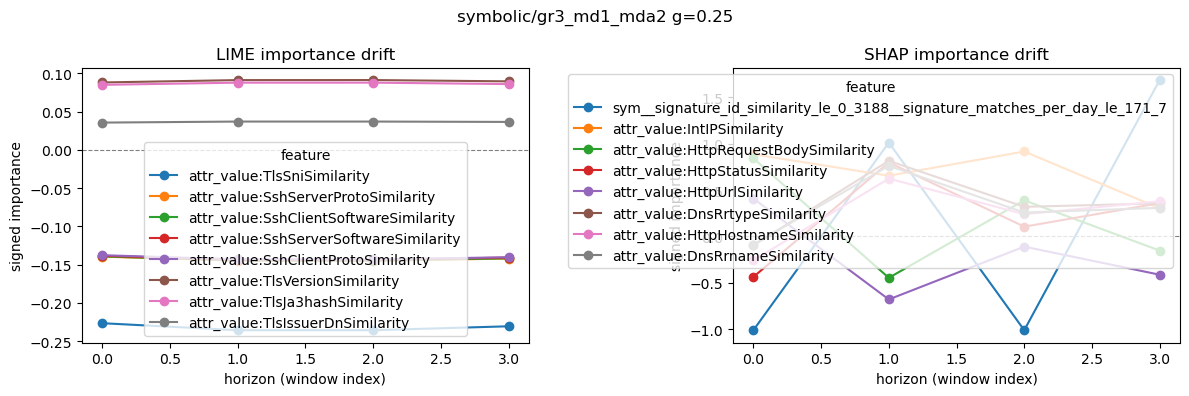

In [9]:
def plot_importance_drift(sub: pd.DataFrame, title: str) -> None:
    methods = sorted(sub["method"].unique())
    fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 4), squeeze=False)
    for j, method in enumerate(methods):
        ax = axes[0][j]
        m = sub[sub["method"] == method]
        top_feats = (
            m.groupby("feature")["importance"]
            .apply(lambda s: s.abs().mean())
            .sort_values(ascending=False)
            .head(TOP_K_FEATURES)
            .index
        )
        pivot = (
            m[m["feature"].isin(top_feats)]
            .pivot(index="horizon_window_index", columns="feature", values="importance")
        )[top_feats]
        pivot.plot(ax=ax, marker="o")
        ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
        ax.set_title(f"{method.upper()} importance drift")
        ax.set_xlabel("horizon (window index)")
        ax.set_ylabel("signed importance")
        # ax.legend(fontsize=7, ncol=2)
    fig.suptitle(title)
    fig.tight_layout()


selected = available_configs.iloc[CONFIG_SELECT]
selected_mask = (explanations[CONFIG_COLS] == selected).all(axis=1)
selected_explanations = explanations[selected_mask]

plot_importance_drift(selected_explanations, config_label(selected))

### SHAP vs. LIME agreement over horizon

Spearman rank correlation between the two methods' signed importances, per
horizon, over every feature both methods reported (not just the top-K
plotted above). A method disagreement that widens with horizon is a sign
the drift itself is destabilizing the explanation, not just the metric.

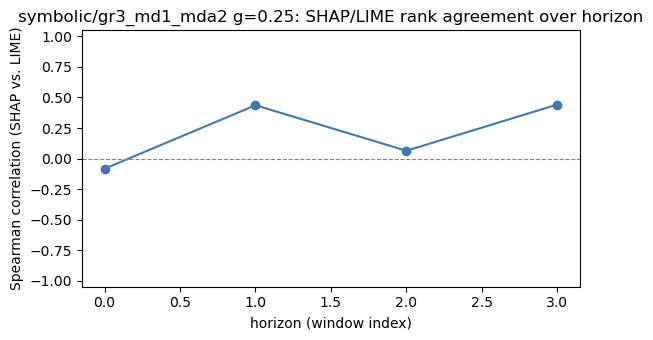

In [10]:
agreement_rows = []
for h, g in selected_explanations.groupby("horizon_window_index"):
    pivot = g.pivot(index="feature", columns="method", values="importance").dropna()
    if len(pivot) >= 2 and {"shap", "lime"} <= set(pivot.columns):
        rho, _ = spearmanr(pivot["shap"], pivot["lime"])
        agreement_rows.append({"horizon_window_index": h, "spearman_shap_lime": rho})

agreement_df = pd.DataFrame(agreement_rows)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(agreement_df["horizon_window_index"], agreement_df["spearman_shap_lime"], "o-", color=LINE_COLOR)
ax.set_ylim(-1.05, 1.05)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("horizon (window index)")
ax.set_ylabel("Spearman correlation (SHAP vs. LIME)")
ax.set_title(f"{config_label(selected)}: SHAP/LIME rank agreement over horizon")
fig.tight_layout()

## 4. LIME local fidelity over horizon

LIME's signed weights (section 3) come from fitting a linear surrogate
locally around each explained point; `lime_fidelity.csv` carries that
surrogate's own R^2 (`Explanation.score`), averaged over each horizon's
explained sample. This is independent of the metric decay in section 1 --
a horizon can still have high AUC while the local decision surface has
become much harder to approximate linearly (falling fidelity), which is a
sign the *shape* of the boundary is drifting, not just its accuracy.

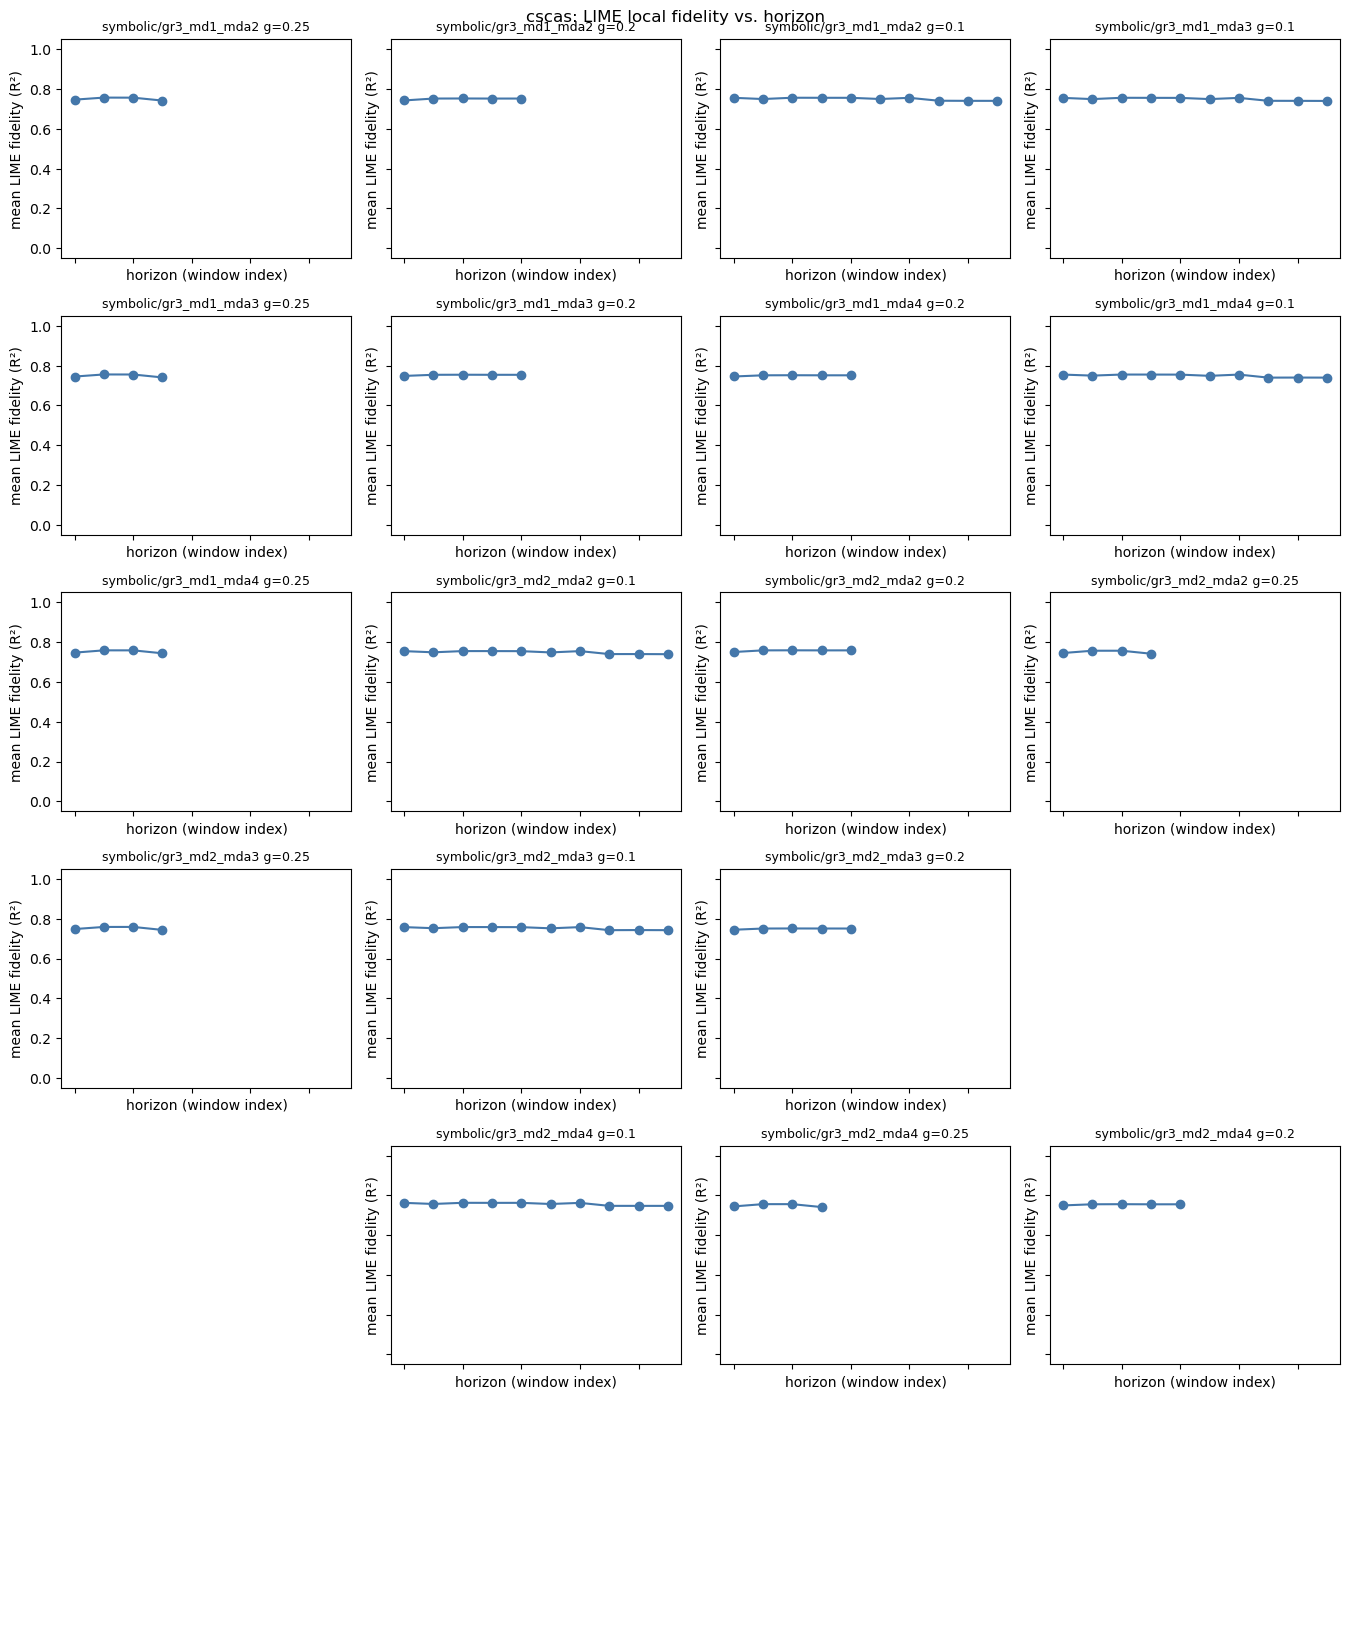

In [11]:
def plot_fidelity_curves(title: str) -> None:
    configs = lime_fidelity[CONFIG_COLS].drop_duplicates().reset_index(drop=True)
    n = len(configs)
    ncols = 4
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.4 * ncols, 2.8 * nrows), squeeze=False, sharex=True, sharey=True
    )

    for i, cfg_row in configs.iterrows():
        ax = axes[i // ncols][i % ncols]
        mask = (lime_fidelity[CONFIG_COLS] == cfg_row).all(axis=1)
        sub = lime_fidelity[mask].sort_values("horizon_window_index")
        if sub.empty:
            ax.axis("off")
            continue

        ax.plot(sub["horizon_window_index"], sub["mean_fidelity"], "o-", color=LINE_COLOR)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(config_label(cfg_row), fontsize=9)
        ax.set_xlabel("horizon (window index)")
        ax.set_ylabel("mean LIME fidelity (R\u00b2)")

    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")

    fig.suptitle(title)
    fig.tight_layout()


plot_fidelity_curves(f"{SCENARIO}: LIME local fidelity vs. horizon")

## 5. Top-k feature-set overlap over horizon

For the selected config (`CONFIG_SELECT`), how much of the top-K
feature *set* at horizon 0 survives at each later horizon -- Jaccard
overlap between `top-K features at h=0` and `top-K features at h`, per
method. This is coarser than the drift lines in section 3 (it doesn't care
which direction a shared feature moved, only whether it's still in the top
set) and cheaper to read at a glance across many horizons.

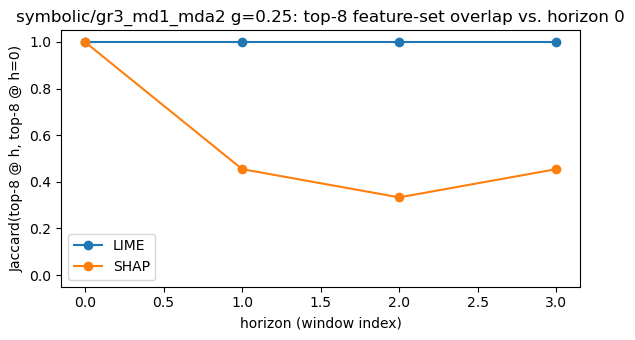

In [12]:
def topk_feature_set(df: pd.DataFrame, method: str, horizon: int, k: int) -> set[str]:
    sub = df[(df["method"] == method) & (df["horizon_window_index"] == horizon)]
    return set(sub.sort_values("rank").head(k)["feature"])


def jaccard(a: set[str], b: set[str]) -> float:
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)


overlap_rows = []
horizons = sorted(selected_explanations["horizon_window_index"].unique())
h0 = horizons[0]
for method in sorted(selected_explanations["method"].unique()):
    ref = topk_feature_set(selected_explanations, method, h0, TOP_K_FEATURES)
    for h in horizons:
        cur = topk_feature_set(selected_explanations, method, h, TOP_K_FEATURES)
        overlap_rows.append({
            "method": method, "horizon_window_index": h,
            "jaccard_vs_h0": jaccard(ref, cur),
        })
overlap_df = pd.DataFrame(overlap_rows)

fig, ax = plt.subplots(figsize=(6, 3.5))
for method, g in overlap_df.groupby("method"):
    ax.plot(g["horizon_window_index"], g["jaccard_vs_h0"], "o-", label=method.upper())
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("horizon (window index)")
ax.set_ylabel(f"Jaccard(top-{TOP_K_FEATURES} @ h, top-{TOP_K_FEATURES} @ h={h0})")
ax.set_title(f"{config_label(selected)}: top-{TOP_K_FEATURES} feature-set overlap vs. horizon {h0}")
ax.legend()
fig.tight_layout()